Model - Val Accuracy - Epochs

Dense - 84.11 - 2

Dense_Improve - 87.06 - 3

CNN - 89.35 - 3

CNN_Improve - 89.79 - 2

RNN - 81.00 - 4

RNN_Improve - 84.37 - 4

LSTM - 84.47 - 2

LSTM_Improve - 85.04 - 3

BiLSTM - 87.01 - 3

BiLSTM - 87.80 - 3

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, SpatialDropout1D, LSTM, Bidirectional
from keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/biLSTM'

# training:
epochs = 6
batch_size = 64

# vector-space embedding:
n_dim = 64
n_unique_words = 10000
max_review_length = 200 # doubled!
pad_type = trunc_type = 'pre'
drop_embed = 0.4

# LSTM layer architecture:
n_lstm = 64
drop_lstm = 0.4

In [ ]:
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words) # removed n_words_to_skip

x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

In [ ]:
model = Sequential()

# 1st hidden layer
model.add(Embedding(n_unique_words, n_dim, input_length=max_review_length))
model.add(SpatialDropout1D(drop_embed))

# 2nd hidden layer
model.add(Bidirectional(LSTM(n_lstm, dropout=drop_lstm)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# LSTM layer parameters double due to both reading directions
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Changed .hdf5 to .keras to satisfy modern Keras requirements
modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/weights.{epoch:02d}.keras")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_valid, y_valid), callbacks=[modelcheckpoint])

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7744 - loss: 0.4598 - val_accuracy: 0.8611 - val_loss: 0.3381
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8862 - loss: 0.2852 - val_accuracy: 0.8780 - val_loss: 0.2934
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9083 - loss: 0.2360 - val_accuracy: 0.8702 - val_loss: 0.3047
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9218 - loss: 0.2040 - val_accuracy: 0.8765 - val_loss: 0.3103
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9297 - loss: 0.1864 - val_accuracy: 0.8580 - val_loss: 0.3993
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9369 - loss: 0.1680 - val_accuracy: 0.8712 - val_loss: 0.3167


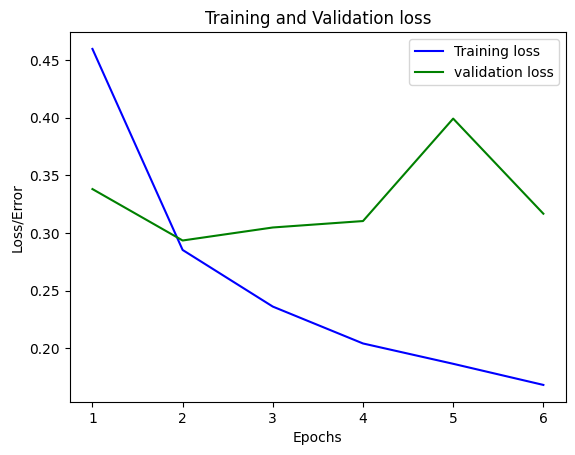

In [ ]:
loss_train = history.history['loss']
loss_val = history.history['val_loss']
epochs = range(1, 7) # range end will be epoch + 1
plt.plot(epochs, loss_train, 'b', label='Training loss')
plt.plot(epochs, loss_val, 'g', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss/Error')
plt.legend()
plt.show()

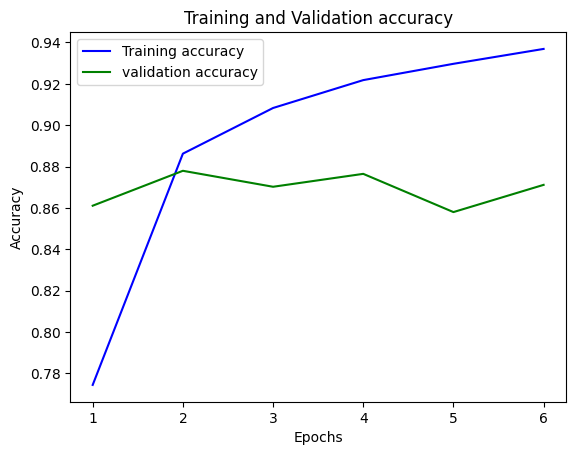

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1, 7) # range end will be epoch + 1
plt.plot(epochs, loss_train, 'b', label='Training accuracy')
plt.plot(epochs, loss_val, 'g', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


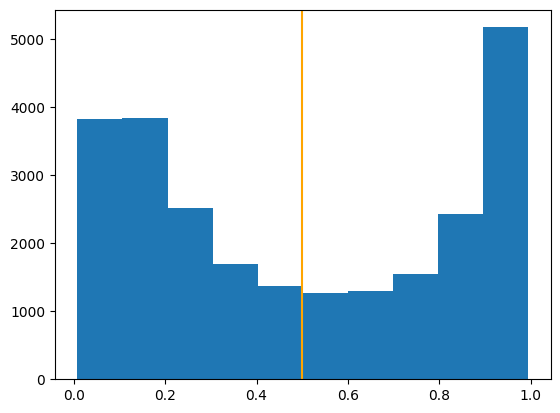

In [ ]:
model.load_weights(output_dir+"/weights.01.keras")

y_hat = model.predict(x_valid)

plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')
plt.show()

93.72


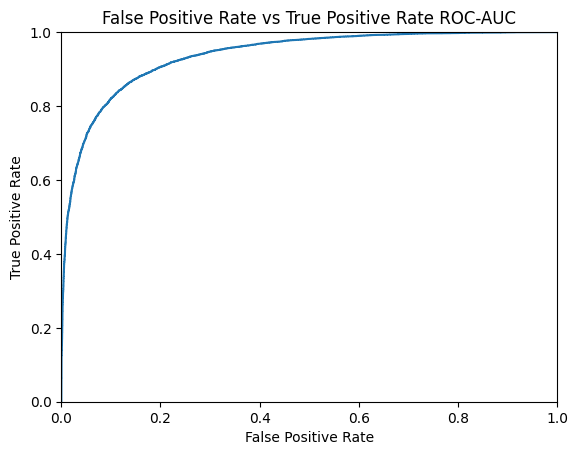

In [ ]:
print("{:0.2f}".format(roc_auc_score(y_valid, y_hat)*100.0))

fpr , tpr , thresholds = roc_curve (y_valid , y_hat)
plt.plot(fpr,tpr)
plt.axis([0,1,0,1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()